In [1]:
!pip install "scikit-learn<1.6.0" -U


zsh:1: command not found: pip


# Taller de Feature Engineering: Seleccion y creacion de variables

Este taller usa el dataset **Coffee Quality Institute - Arabica**, con 1,311 lotes de cafe evaluados, para predecir `Total.Cup.Points`, el puntaje final de cata.

Un detalle importante antes de empezar: `Total.Cup.Points` resulta de sumar 10 subpuntajes (`Aroma`, `Flavor`, `Aftertaste`, entre otros) que tambien estan disponibles en el dataset. Se descartaron intencionalmente esas columnas como predictoras, ya que incluirlas generaria fuga de datos: el modelo terminaria reconstruyendo la respuesta en vez de aprender patrones utiles. Por eso la prediccion se basa unicamente en variables relacionadas con el proceso de produccion y el origen del cafe.

In [2]:
%pip install -q pandas numpy scikit-learn matplotlib category_encoders optuna openpyxl


You should consider upgrading via the '/Applications/Xcode.app/Contents/Developer/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [3]:
import re
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

from category_encoders import TargetEncoder

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

SEMILLA = 42


# 1. Carga de datos y limpieza inicial

In [4]:
df = pd.read_excel("arabica_data_excel.xlsx")
print(f"Filas: {df.shape[0]} | Columnas: {df.shape[1]}")
df.head()


Filas: 1311 | Columnas: 44


,ID,Species,Owner,Country.of.Origin,Farm.Name,Lot.Number,Mill,ICO.Number,Company,Altitude,...,Color,Category.Two.Defects,Expiration,Certification.Body,Certification.Address,Certification.Contact,unit_of_measurement,altitude_low_meters,altitude_high_meters,altitude_mean_meters
0,1,Arabica,metad plc,Ethiopia,metad plc,NaN,metad plc,2014/2015,metad agricultural developmet plc,1950-2200,...,Green,0,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1950.0,2200.0,2075.0
1,2,Arabica,metad plc,Ethiopia,metad plc,NaN,metad plc,2014/2015,metad agricultural developmet plc,1950-2200,...,Green,1,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1950.0,2200.0,2075.0
2,3,Arabica,grounds for health admin,Guatemala,"san marcos barrancas ""san cristobal cuch",NaN,NaN,NaN,NaN,1600 - 1800 m,...,NaN,0,"May 31st, 2011",Specialty Coffee Association,36d0d00a3724338ba7937c52a378d085f2172daa,0878a7d4b9d35ddbf0fe2ce69a2062cceb45a660,m,1600.0,1800.0,1700.0
3,4,Arabica,yidnekachew dabessa,Ethiopia,yidnekachew dabessa coffee plantation,NaN,wolensu,NaN,yidnekachew debessa coffee plantation,1800-2200,...,Green,2,"March 25th, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1800.0,2200.0,2000.0
4,5,Arabica,metad plc,Ethiopia,metad plc,NaN,metad plc,2014/2015,metad agricultural developmet plc,1950-2200,...,Green,2,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1950.0,2200.0,2075.0


In [5]:
#Buscamos registros con nota final en 0, lo que indicaria una evaluacion incompleta
df[df["Total.Cup.Points"] == 0][["Total.Cup.Points", "Aroma", "Flavor"]]

,Total.Cup.Points,Aroma,Flavor
1310,0.0,0.0,0.0


In [6]:
#Confirmamos que se trata de un registro invalido (todos los valores en 0) y lo eliminamos
df = df[df["Total.Cup.Points"] > 0].copy()
print(f"Filas despues de eliminar el registro invalido: {len(df)}")

Filas despues de eliminar el registro invalido: 1310


Tambien se revisa `altitude_mean_meters` y se detectan valores fisicamente imposibles (190,164 y 110,000 metros, cuando el Everest mide apenas 8,849m). Esta correccion se deja intencionalmente para la Fase 2, tal como lo pide la actividad, en vez de limpiarla desde el inicio.

# 2. Seleccion de variables predictoras

Se excluyen las 10 subnotas de cata junto con columnas que no aportan valor predictivo (identificadores, texto libre, campos redundantes). Las variables que se conservan son: `Processing.Method` y `Color` (categoricas de baja cardinalidad); `Country.of.Origin`, `Variety` y `Certification.Body` (categoricas de alta cardinalidad); y un grupo de variables numericas (numero de sacos, humedad, defectos, altitud, año de cosecha), ademas de la fecha de calificacion.

In [7]:
y = df["Total.Cup.Points"]

#Harvest.Year tiene formatos poco consistentes; extraemos el primer anio valido con una expresion regular
def extraer_anio(valor):
    if pd.isna(valor):
        return np.nan
    coincidencia = re.search(r"(19|20)\d{2}", str(valor))
    return float(coincidencia.group(0)) if coincidencia else np.nan

df["harvest_year"] = df["Harvest.Year"].apply(extraer_anio)

#Grading.Date tambien presenta formatos irregulares, usamos errors="coerce" para convertir sin fallar
df["grading_date_parsed"] = pd.to_datetime(df["Grading.Date"], errors="coerce")
df["grading_month"] = df["grading_date_parsed"].dt.month

cat_baja_card = ["Processing.Method", "Color"]
cat_alta_card = ["Country.of.Origin", "Variety", "Certification.Body"]
numericas = ["Number.of.Bags", "Moisture", "Category.One.Defects", "Category.Two.Defects",
             "Quakers", "altitude_mean_meters", "harvest_year"]

X = df[cat_baja_card + cat_alta_card + numericas + ["grading_month"]].copy()

In [8]:
def evaluar(nombre, y_true, y_pred):
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    print(f"{nombre}: RMSE={rmse:.4f}  R2={r2:.4f}  MAE={mae:.4f}")
    return {"modelo": nombre, "RMSE": rmse, "R2": r2, "MAE": mae}

resultados = []

# 3. Fase 1: Modelo Baseline

El punto de partida es un modelo con limpieza minima, de forma deliberada: la altitud queda sin corregir, todas las categoricas (incluidas las de alta cardinalidad) se codifican con One-Hot, la fecha de calificacion todavia no se usa, y solo se aplica una imputacion basica de valores faltantes.

In [9]:
cols_baseline = cat_baja_card + cat_alta_card + numericas

#El split train/test se hace antes de cualquier limpieza, para evitar filtrar informacion del test
X_train, X_test, y_train, y_test = train_test_split(X[cols_baseline], y, test_size=0.2, random_state=SEMILLA)

#Preprocesamiento deliberadamente minimo: One-Hot para todas las categoricas (incluso las de
#alta cardinalidad) y solo imputacion de nulos, sin corregir la altitud ni aplicar tecnicas de
#feature engineering todavia (eso se aborda en la Fase 2)
preprocesador_baseline = ColumnTransformer(transformers=[
    ("categoricas", Pipeline([
        ("imputar", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]), cat_baja_card + cat_alta_card),
    ("numericas", SimpleImputer(strategy="median"), numericas),
])

#Modelo de referencia: Random Forest con hiperparametros por defecto (todavia sin ajustar)
modelo_baseline = Pipeline([
    ("preprocesamiento", preprocesador_baseline),
    ("modelo", RandomForestRegressor(random_state=SEMILLA)),
])

modelo_baseline.fit(X_train, y_train)

#Guardamos las metricas de este modelo base para compararlas mas adelante con las versiones mejoradas
resultados.append(evaluar("1. Baseline", y_test, modelo_baseline.predict(X_test)))

#Contamos cuantas columnas resultan del One-Hot al incluir las 3 variables de alta cardinalidad;
#sirve de referencia para comparar contra la reduccion que se logra despues con Target Encoding
n_columnas_baseline = preprocesador_baseline.fit_transform(X_train, y_train).shape[1]
print(f"Columnas tras preprocesar: {n_columnas_baseline}")

1. Baseline: RMSE=2.2433  R2=0.2895  MAE=1.5497
Columnas tras preprocesar: 100


# 4. Fase 2: Ingenieria de Caracteristicas

En esta fase se aplican cuatro tecnicas de feature engineering sobre los datos.

## 4.1 Distribucion: transformacion log1p

`Number.of.Bags` y los conteos de defectos presentan distribuciones sesgadas, con colas largas hacia la derecha. Se aplica `log1p` para atenuar ese sesgo.

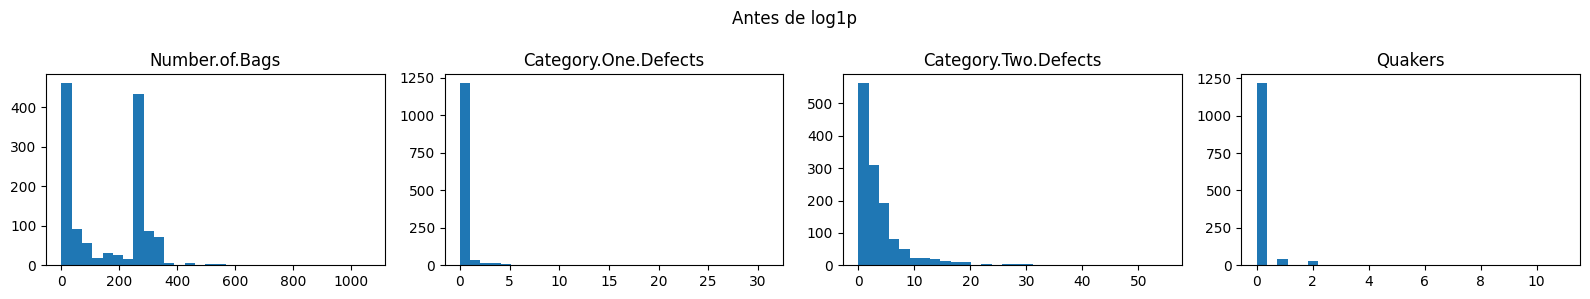

In [10]:
columnas_sesgadas = ["Number.of.Bags", "Category.One.Defects", "Category.Two.Defects", "Quakers"]

fig, ejes = plt.subplots(1, len(columnas_sesgadas), figsize=(16, 3))
for eje, col in zip(ejes, columnas_sesgadas):
    eje.hist(X[col].dropna(), bins=30)
    eje.set_title(col)
plt.suptitle("Antes de log1p")
plt.tight_layout()
plt.show()

for col in columnas_sesgadas:
    X[col] = np.log1p(X[col])


## 4.2 Outliers: variable indicadora y winsorization sobre la altitud

Cualquier valor de altitud superior a 3,000 metros (o negativo/cero) se marca como invalido, se convierte en NaN y queda registrado en `altitud_invalida`. Sobre los valores restantes se aplica winsorization, recortando en los percentiles 1 y 99.

In [11]:
ALTITUD_MAXIMA_VALIDA = 3000

X["altitud_invalida"] = ((X["altitude_mean_meters"] > ALTITUD_MAXIMA_VALIDA) | (X["altitude_mean_meters"] <= 0)).astype(int)
print(f"Altitudes marcadas como invalidas: {X['altitud_invalida'].sum()}")
X.loc[X["altitud_invalida"] == 1, "altitude_mean_meters"] = np.nan


class LimitadorCuantiles(BaseEstimator, TransformerMixin):
    """Recorta valores extremos usando cuantiles calculados solo con el train, evitando fuga de informacion del test."""

    def __init__(self, inferior=0.01, superior=0.99):
        self.inferior = inferior
        self.superior = superior

    def fit(self, X, y=None):
        m = np.asarray(X, dtype=float)
        self.li_ = np.nanquantile(m, self.inferior, axis=0)
        self.ls_ = np.nanquantile(m, self.superior, axis=0)
        return self

    def transform(self, X):
        m = np.asarray(X, dtype=float)
        return np.clip(m, self.li_, self.ls_)

Altitudes marcadas como invalidas: 14


## 4.3 Encoding: Target Encoding para alta cardinalidad

`Country.of.Origin`, `Variety` y `Certification.Body` tienen demasiadas categorias para codificarlas con One-Hot sin disparar la dimensionalidad. En su lugar se usa Target Encoding, calculado unicamente con el conjunto de entrenamiento y dentro del Pipeline, para no filtrar informacion del test.

In [12]:
#Ejemplo ilustrativo de Target Encoding aplicado a Country.of.Origin, ajustado solo con el train
demo_encoder = TargetEncoder()
pais_codificado = demo_encoder.fit_transform(X_train[["Country.of.Origin"]], y_train)

print(f"Country.of.Origin tiene {X_train['Country.of.Origin'].nunique()} categorias distintas")

tabla_demo = X_train[["Country.of.Origin"]].reset_index(drop=True).copy()
tabla_demo["valor_codificado"] = pais_codificado["Country.of.Origin"].reset_index(drop=True)
tabla_demo.drop_duplicates().sort_values("valor_codificado", ascending=False).head(10)

Country.of.Origin tiene 33 categorias distintas


,Country.of.Origin,valor_codificado
4,Ethiopia,85.189214
5,Kenya,83.255240
12,Uganda,83.195508
0,Colombia,83.131080
151,United States,82.973941
21,Costa Rica,82.809725
533,Papua New Guinea,82.660067
91,El Salvador,82.520300
773,Japan,82.519550
133,China,82.463888


## 4.4 Variables ciclicas: seno y coseno del mes

El mes de calificacion se transforma en sus componentes seno y coseno, de modo que diciembre y enero queden numericamente cerca (como enteros quedarian lejos: 12 frente a 1).

In [13]:
mes_imputado = X["grading_month"].fillna(X["grading_month"].median())
X["mes_sin"] = np.sin(2 * np.pi * mes_imputado / 12)
X["mes_cos"] = np.cos(2 * np.pi * mes_imputado / 12)


In [14]:
X[["mes_sin","mes_cos","grading_month"]]

,mes_sin,mes_cos,grading_month
0,8.660254e-01,-5.000000e-01,4.0
1,8.660254e-01,-5.000000e-01,4.0
2,1.224647e-16,-1.000000e+00,NaN
3,1.000000e+00,6.123234e-17,3.0
4,8.660254e-01,-5.000000e-01,4.0
...,...,...,...
1305,5.000000e-01,-8.660254e-01,5.0
1306,-1.000000e+00,-1.836970e-16,9.0
1307,5.000000e-01,-8.660254e-01,5.0
1308,1.224647e-16,-1.000000e+00,6.0


In [15]:
numericas_fe = numericas + ["altitud_invalida", "mes_sin", "mes_cos"]
cols_fe = cat_baja_card + cat_alta_card + numericas_fe

X_train, X_test, y_train, y_test = train_test_split(X[cols_fe], y, test_size=0.2, random_state=SEMILLA)


def construir_preprocesador():
    return ColumnTransformer(transformers=[
        ("cat_baja_card", Pipeline([
            ("imputar", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]), cat_baja_card),
        ("cat_alta_card", Pipeline([
            ("imputar", SimpleImputer(strategy="most_frequent")),
            ("target_encoding", TargetEncoder()),
        ]), cat_alta_card),
        ("altitud", Pipeline([
            ("imputar", SimpleImputer(strategy="median")),
            ("winsorization", LimitadorCuantiles(0.01, 0.99)),
        ]), ["altitude_mean_meters"]),
        ("resto_numericas", SimpleImputer(strategy="median"),
         [c for c in numericas_fe if c != "altitude_mean_meters"]),
    ])


modelo_fe = Pipeline([
    ("preprocesamiento", construir_preprocesador()),
    ("modelo", RandomForestRegressor(random_state=SEMILLA)),
])
modelo_fe.fit(X_train, y_train)
resultados.append(evaluar("2. Solo Feature Engineering", y_test, modelo_fe.predict(X_test)))

n_columnas_fe = construir_preprocesador().fit_transform(X_train, y_train).shape[1]
print(f"Columnas tras preprocesar con FE: {n_columnas_fe} (antes {n_columnas_baseline})")


2. Solo Feature Engineering: RMSE=2.1379  R2=0.3547  MAE=1.4839
Columnas tras preprocesar con FE: 21 (antes 100)


# 5. Fase 3: Optimizacion con Optuna

Se define un espacio de busqueda para los hiperparametros del Random Forest y se usa Optuna para encontrar la mejor combinacion, validando cada una con 5 folds de validacion cruzada sobre el conjunto de entrenamiento.

In [16]:
#Esta funcion objetivo es la que Optuna invoca repetidamente, cada vez probando una
#combinacion distinta de hiperparametros para identificar cual funciona mejor
def funcion_objetivo(trial):
    #Rango de valores permitido para cada hiperparametro durante la busqueda
    parametros = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "max_depth": trial.suggest_int("max_depth", 3, 30),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 20),
        "max_features": trial.suggest_float("max_features", 0.3, 1.0),
    }
    modelo = Pipeline([
        ("preprocesamiento", construir_preprocesador()),
        ("modelo", RandomForestRegressor(random_state=SEMILLA, **parametros)),
    ])
    #Se usa validacion cruzada de 5 folds sobre el train (sin tocar el test en ningun momento)
    #para estimar que tan buena es esta combinacion de hiperparametros
    cv = KFold(n_splits=5, shuffle=True, random_state=SEMILLA)
    puntajes = cross_val_score(modelo, X_train, y_train, cv=cv, scoring="neg_root_mean_squared_error", n_jobs=-1)
    return -puntajes.mean()  #Se devuelve el valor negativo porque Optuna minimiza la funcion objetivo


#Se crea el estudio de Optuna y se ejecutan 40 intentos (40 combinaciones distintas de hiperparametros)
estudio = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEMILLA))
estudio.optimize(funcion_objetivo, n_trials=40)

print("Mejores hiperparametros:", estudio.best_params)
print(f"Mejor RMSE (CV): {estudio.best_value:.4f}")

Mejores hiperparametros: {'n_estimators': 396, 'max_depth': 23, 'min_samples_leaf': 1, 'max_features': 0.32467525600041114}
Mejor RMSE (CV): 2.2531


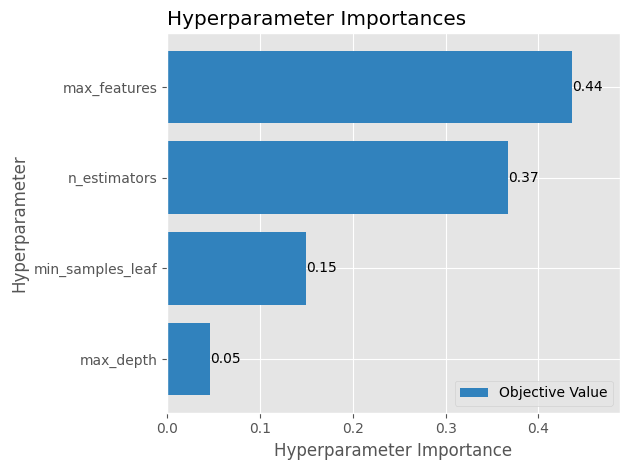

In [17]:
import optuna.visualization.matplotlib as optuna_mpl

optuna_mpl.plot_param_importances(estudio)
plt.tight_layout()
plt.show()


In [18]:
modelo_optimizado = Pipeline([
    ("preprocesamiento", construir_preprocesador()),
    ("modelo", RandomForestRegressor(random_state=SEMILLA, **estudio.best_params)),
])
modelo_optimizado.fit(X_train, y_train)
resultados.append(evaluar("3. Feature Engineering + Optuna", y_test, modelo_optimizado.predict(X_test)))


3. Feature Engineering + Optuna: RMSE=2.0734  R2=0.3930  MAE=1.4323


# 6. Fase 4: Comparativa final

In [19]:
tabla_comparativa = pd.DataFrame(resultados).set_index("modelo")
tabla_comparativa


,RMSE,R2,MAE
modelo,,,
1. Baseline,2.243317,0.289478,1.549698
2. Solo Feature Engineering,2.137893,0.354690,1.483898
3. Feature Engineering + Optuna,2.073438,0.393014,1.432258


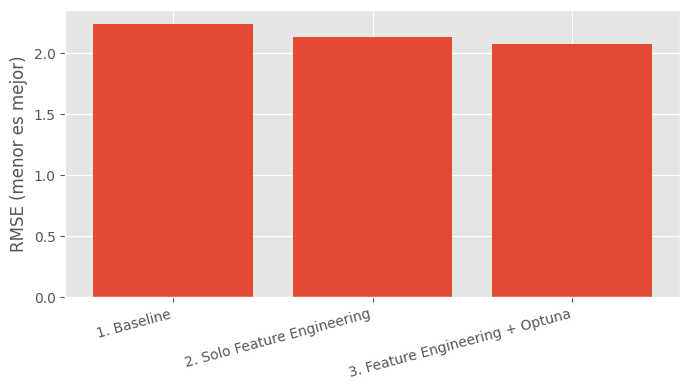

In [20]:
fig, eje = plt.subplots(figsize=(7, 4))
eje.bar(tabla_comparativa.index, tabla_comparativa["RMSE"])
eje.set_ylabel("RMSE (menor es mejor)")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()


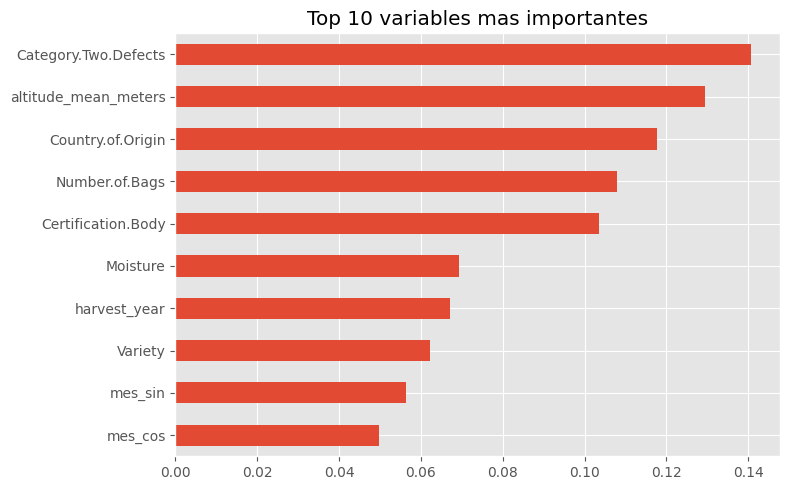

Category.Two.Defects    0.140715
altitude_mean_meters    0.129424
Country.of.Origin       0.117715
Number.of.Bags          0.107825
Certification.Body      0.103535
Moisture                0.069370
harvest_year            0.067009
Variety                 0.062149
mes_sin                 0.056298
mes_cos                 0.049656
dtype: float64

In [21]:
nombres_onehot = list(
    modelo_optimizado.named_steps["preprocesamiento"]
    .named_transformers_["cat_baja_card"].named_steps["onehot"]
    .get_feature_names_out(cat_baja_card)
)
nombres_columnas = nombres_onehot + cat_alta_card + ["altitude_mean_meters"] + [c for c in numericas_fe if c != "altitude_mean_meters"]

importancias = pd.Series(
    modelo_optimizado.named_steps["modelo"].feature_importances_, index=nombres_columnas
).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
importancias.head(10).plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Top 10 variables mas importantes")
plt.tight_layout()
plt.show()

importancias.head(10)


## Conclusion

El modelo baseline arranco con un RMSE de 2.25 y un R2 de 0.28. Al aplicar las cuatro tecnicas de feature engineering (log1p, correccion de la altitud con variable indicadora y winsorization, target encoding y variables ciclicas), sin tocar los hiperparametros del modelo, el RMSE bajo a 2.13 y el R2 subio a 0.36. Sumando la optimizacion de hiperparametros con Optuna, el RMSE se redujo hasta 2.06 y el R2 llego a 0.40, el mejor resultado de los tres modelos evaluados.

Al revisar la importancia de variables del modelo final, el Target Encoding parece ser la tecnica de mayor impacto: dos de las tres variables de alta cardinalidad codificadas de esta forma (Country.of.Origin y Certification.Body) quedan entre las cinco mas relevantes, y esta tecnica permitio reducir las columnas generadas de 100 (con One-Hot) a solo 21. El tratamiento de la altitud tambien resulto determinante, ya que se ubico como la segunda variable individual mas importante del modelo; corregir esos valores imposibles (190,164 metros, muy por encima del Everest) no era un detalle menor, sino una fuente real de ruido para el modelo.